In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
import itertools
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.8',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.4',
                'lemon_creek':'58.5_-134.4',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too hPPigh --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

gulkana T lapse_rate -3.5
Summer mass balance MAE: 0.23435333649872753
Winter mass balance MAE: 0.13295703356975552
Summer mass balance bias: 0.12292313383331567
Winter mass balance bias: 0.005098423594685898


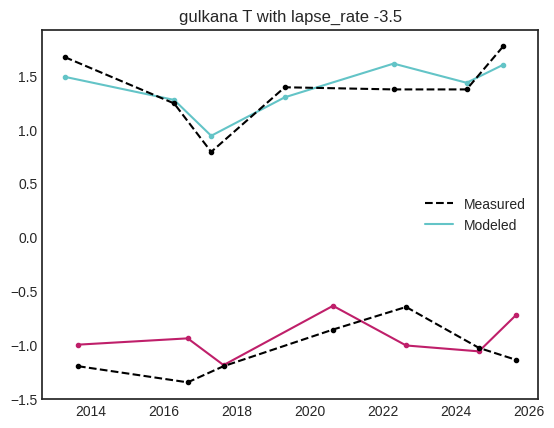

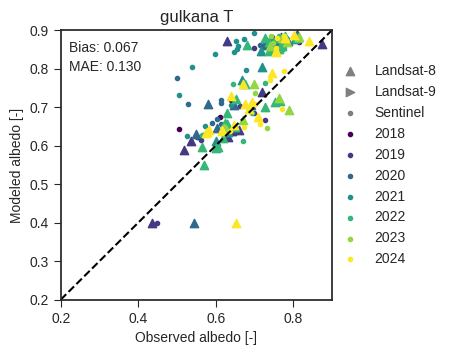

gulkana Z lapse_rate -3.5
Summer mass balance MAE: 0.5812496399623645
Winter mass balance MAE: 0.5940852102283284
Summer mass balance bias: -0.3101840712702199
Winter mass balance bias: 0.2430892972242582


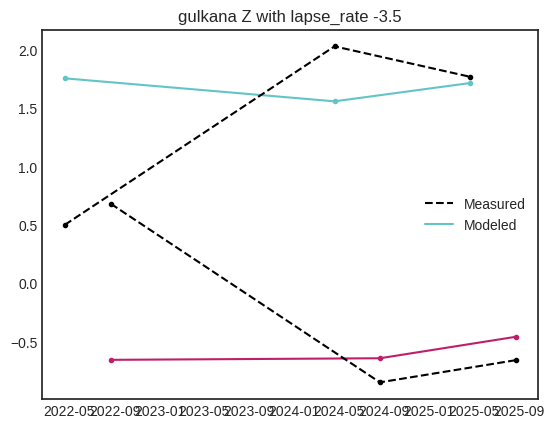

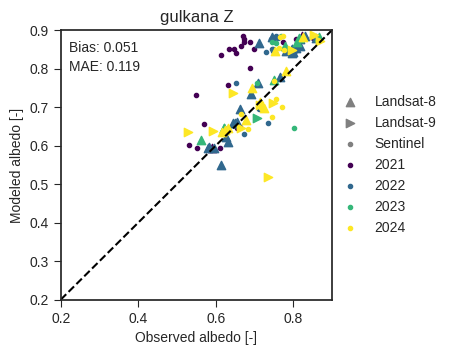

kahiltna KPS lapse_rate -3.5
Summer mass balance MAE: 0.8640637695313577
Winter mass balance MAE: 0.7233846573949778
Summer mass balance bias: 0.18319214693404998
Winter mass balance bias: -0.5378143366827132


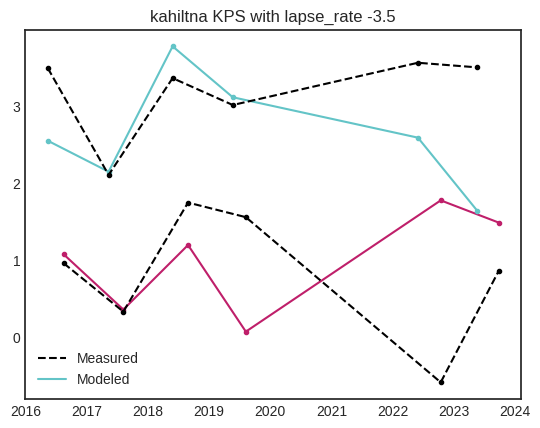

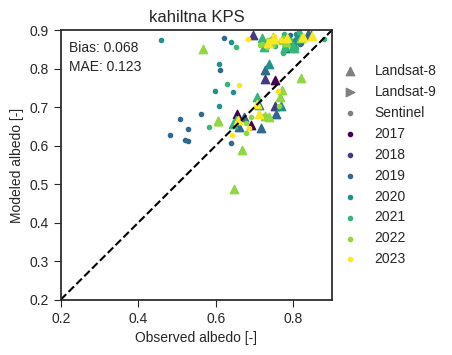

kahiltna KQU lapse_rate -7
Summer mass balance MAE: 0.017644792107391172
Winter mass balance MAE: 0.01607078023596309
Summer mass balance bias: -0.017644792107391172
Winter mass balance bias: -0.01607078023596309


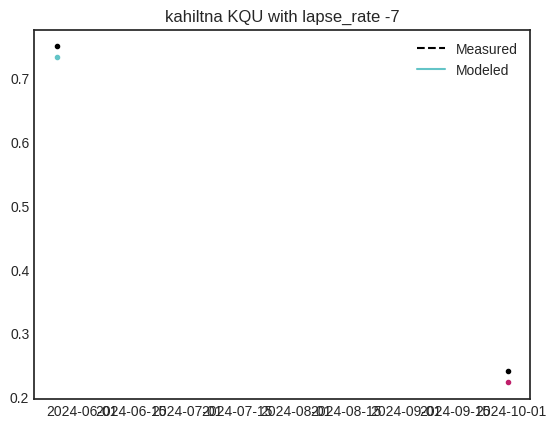

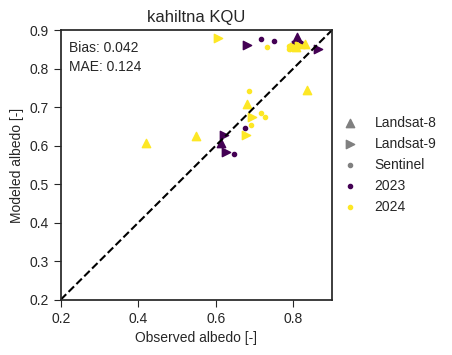

wolverine EC lapse_rate -9
Summer mass balance MAE: 0.38033295283838753
Winter mass balance MAE: 0.5392984167898808
Summer mass balance bias: 0.04976707353410749
Winter mass balance bias: 0.4896108247700642


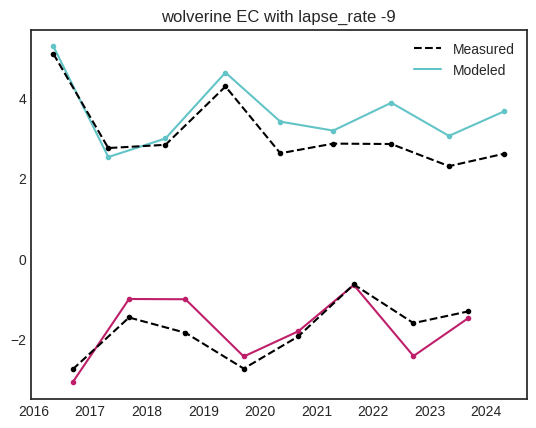

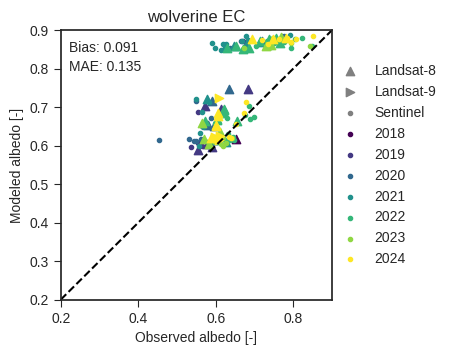

In [4]:
params = {
    # 'wind_factor':[0.5, 1, 1.5, 2, 2.5, 3, 3.5],
    # 'lapse_rate':[ -3, -6.5, -9]
    # 'lapse_rate':[-6.5], 
    # 'wind_factor':[1],
    'lapse_rate':[ -3.5, -4, -4.5, -5, -5.5, -6, -6.5, -7, -7.5, -8, -8.5, -9],
}

site_dict = {'gulkana':['T','Z'],
             'kahiltna':['KPS', 'KQU'],
             'wolverine':['EC']}

keys = list(params.keys())
values = list(params.values())

fn = 'paper2/recalibrate_{s}/grid_{g}_{s}_{p}_fixed_0.nc'

all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
snow_only = True
for glacier in site_dict:
    if glacier not in best_dict: best_dict[glacier] = {}
    
    for site in site_dict[glacier]:
        best = np.inf 

        for param_values in itertools.product(*values):
            params_str = '_'.join([p.replace('_','') + str(v) for p, v in zip(keys, param_values)])
            fn_ds = base_fp + fn.format(g=glacier, s=site, p=params_str)
            try:
                ds = xr.open_dataset(fn_ds)
                assert ds.melt.sum() != 0
            except:
                continue

            albedo_data = Albedo(glacier, site, use='all')
            albedo_data.get_model_albedo(ds, snow_only=snow_only)
            mb_data = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
            mb_data.get_model_mb(ds)

            if mb_data.dataset == 'seasonal':
                error , _= mb_data.mae(True)
            else:
                error = mb_data.mae()

            if error < best:
                best = error 
                best_ds = ds.load()
                best_params = param_values

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(best_ds, snow_only=snow_only)
        mb_data = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
        mb_data.get_model_mb(best_ds)

        best_str = ' '.join([p+' '+str(v) for p, v in zip(keys, best_params)])
        print(glacier, site, best_str)
        best_dict[glacier][site] = {'lapse_rate': best_params[0]}
        
        if mb_data.dataset == 'seasonal':
            mae_summer, mae_winter = mb_data.mae(True)
            print('Summer mass balance MAE:',mae_summer)
            print('Winter mass balance MAE:',mae_winter)

            me_summer, me_winter = mb_data.bias(True)
            print('Summer mass balance bias:',me_summer)
            print('Winter mass balance bias:',me_winter)
        else:
            print('Annual mass balance MAE:',mb_data.mae())
            print('Annual mass balance bias', mb_data.bias())

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

        # plot
        fig, ax = mb_data.plot_mb()
        ax.set_title(f'{glacier} {site} with {best_str}')
        plt.savefig(base_fp + f'../figs/{glacier+site}_best_mb.png')
        plt.show()
        plt.close()
        
        # albedo_data.plot_timeseries()
        albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)


In [3]:
for glacier in best_dict:
    for site in best_dict[glacier]:
        best_dict[glacier][site] = {'wind_factor':best_dict[glacier][site][0],
                                    'lapse_rate': best_dict[glacier][site][1]}
        
best_dict

{'gulkana': {'T': {'wind_factor': 3.5, 'lapse_rate': -6.5},
  'Z': {'wind_factor': 3.5, 'lapse_rate': -6.5}},
 'kahiltna': {'KPS': {'wind_factor': 3, 'lapse_rate': -6.5},
  'KQU': {'wind_factor': 2.5, 'lapse_rate': -6.5}},
 'wolverine': {'EC': {'wind_factor': 2, 'lapse_rate': -6.5}}}

In [5]:
import pickle
pickle_name = 'best_firn_params.pkl'
if False: # os.path.exists(pickle_name):
    with open(pickle_name, 'rb') as f:
        best_dict = pickle.load(f)
else:
    with open(pickle_name, 'wb') as f:
        pickle.dump(best_dict, f)
best_dict

{'gulkana': {'T': {'lapse_rate': -3.5}, 'Z': {'lapse_rate': -3.5}},
 'kahiltna': {'KPS': {'lapse_rate': -3.5}, 'KQU': {'lapse_rate': -7}},
 'wolverine': {'EC': {'lapse_rate': -9}}}

In [ ]:
# # TROUBLESHOOTING FIGURE: ALBEDO TIMESERIES IN EACH YEAR FOR EACH GLACIER 
# plot = False
# snow_only = False 
# deltas = True 
# fn = 'ddf/grid_{g}_{s}_windfactor{w}_0.nc'

# glaciers = ['gulkana','kennicott', 'wolverine', 'lemon_creek', 'kahiltna']
# sites = [['B','D'], ['GTL','GTH'], ['N','EC'], ['B','D'], ['K53','K17b']]
# all_meas_albedo = [] 
# all_mod_albedo = []
# all_time_albedo = []

# for (g, (site1, site2)) in zip(glaciers, sites):
#     # load datasets
#     ds1 = xr.open_dataset(base_fp + fn.format(g=g, s=site1, w=best_dict[g][site1]))
#     ds2 = xr.open_dataset(base_fp + fn.format(g=g, s=site2, w=best_dict[g][site2]))

#     # get observations
#     a1 = Albedo(g, site1)
#     a2 = Albedo(g, site2)

#     # process model
#     a1.get_model_albedo(ds1, snow_only=snow_only)
#     a2.get_model_albedo(ds2, snow_only=snow_only)
#     if deltas:
#         a1.get_deltas()
#         a2.get_deltas()
#     for a in [a1, a2]:
#         for meas, mod, t in zip(a.meas, a.mod, a.time):
#             all_meas_albedo.append(meas)
#             all_mod_albedo.append(mod)
#             all_time_albedo.append(t)

#     if plot:
#         years = np.arange(2019, 2025)
#         fig, axes = plt.subplots(2, 3, figsize=(8, 6), gridspec_kw={'hspace':0.3, 'wspace': 0.3})
#         axes = axes.flatten()
#         for yr, ax in zip(years, axes):
#             dates = pd.date_range(f'{yr}-04-01',f'{yr}-08-20')

#             for i, a in enumerate([a1, a2]):
#                 time, mod, meas = a.get_dates(dates)
#                 if i == 0: ax.scatter(time, meas, label='Satellite')
#                 else: ax.scatter(time, meas)
#                 ax.plot(time, mod, label=site)

#             # if g == 'gulkana':
#             #     if yr == 2024:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkana2024_walbedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[pd.date_range(f'{yr}-04-20',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             #     elif yr == 2025:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkanaB2025_albedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[df.index.hour.isin(range(13, 15))].resample('d').mean()
#             #         df = df.loc[pd.date_range(f'{yr}-04-23',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             # ax.set_xlim(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'))
#             ax.set_xticks(pd.date_range(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'), freq='2MS'))
#             ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%Y'))
#             ax.minorticks_on()
#             ax.tick_params(length=5)
#         ax.legend()
#         name = ' '.join(g.split('_')).capitalize()
#         fig.suptitle(name, y=0.93)
#         plt.savefig(base_fp + f'../figs/ddf/albedo_comparison_{g}.png', bbox_inches='tight')
#         plt.show()

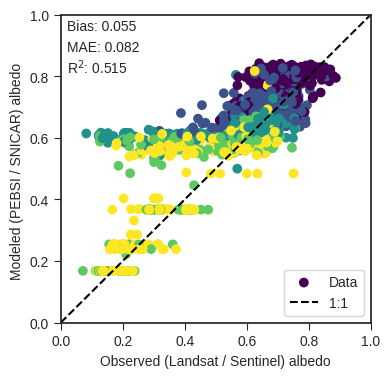

In [16]:
fn = 'ddf/{g}{s}_2026_05_08_base_0.nc'
all_meas_albedo = [] 
all_mod_albedo = []
all_time_albedo = []
deltas = False
snow_only = False

for glacier in site_dict:
    for site in site_dict[glacier]:    
        ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
        assert ds.melt.sum() > 0, 'did not save'
        albedo = Albedo(glacier, site)
        albedo.get_model_albedo(ds, snow_only=snow_only)
        if deltas:
            albedo.get_deltas()

        for meas, mod, t in zip(albedo.meas, albedo.mod, albedo.time):
            all_meas_albedo.append(meas)
            all_mod_albedo.append(mod)
            all_time_albedo.append(t)

fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
if deltas:
    minval, maxval = -0.7, 0.02
else:
    minval, maxval = 0, 1
ax.plot([minval, maxval],[minval, maxval],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(minval, maxval)
ax.set_ylim(minval, maxval)
ax.tick_params(length=5)
if not deltas:
    ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
    ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
else:
    ax.set_ylabel('$\Delta$ Modeled (PEBSI / SNICAR) albedo')
    ax.set_xlabel('$\Delta$ Observed (Landsat / Sentinel) albedo')
deltastr = '_deltas' if deltas else ''
plt.savefig(f'/trace/group/rounce/cvwilson/figs/ddf/albedo{deltastr}.png', bbox_inches='tight', dpi=300)
plt.show()

taku TKG3 ['2020-09-29T00:00:00.000000000' '2020-09-30T00:00:00.000000000'
 '2020-10-01T00:00:00.000000000' '2020-10-02T00:00:00.000000000'
 '2020-10-03T00:00:00.000000000']
kahiltna K53 ['2015-05-09T00:00:00.000000000' '2015-05-10T00:00:00.000000000'
 '2015-05-11T00:00:00.000000000' '2015-05-12T00:00:00.000000000'
 '2015-05-13T00:00:00.000000000']
lemon_creek B ['2020-09-25T00:00:00.000000000' '2020-09-26T00:00:00.000000000'
 '2020-09-27T00:00:00.000000000' '2020-09-28T00:00:00.000000000']
lemon_creek C ['2020-10-04T00:00:00.000000000' '2020-10-05T00:00:00.000000000'
 '2020-10-06T00:00:00.000000000' '2020-10-07T00:00:00.000000000'
 '2020-10-08T00:00:00.000000000']


/tmp/ipykernel_517294/1571522312.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


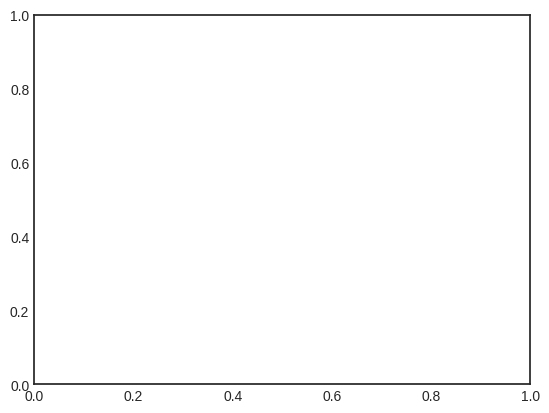

In [66]:
glacier, site = 'wolverine','B'
for glacier in ['taku','kahiltna', 'lemon_creek']:
    for site in site_dict[glacier]:
        ds = xr.open_dataset(base_fp + 'ddf/{g}{s}_2026_05_08_base_0.nc'.format(g=glacier, s=site))
        snow_depth = ds['layerheight'].where(ds['layertype'] < 1).sum(dim='layer').resample(time='1d').min()

        dsa = ds.albedo.sel(time=pd.date_range(ds.time.values[0], ds.time.values[-1]))
        dsa = dsa.where(snow_depth > 0.05)
        # plt.hist(ds.values, label=glacier+site)
        time_weird = dsa.where(dsa < 0.45, drop=True).time.values[:5]
        if len(time_weird) > 0:
            k = ds.sel(time=time_weird)
            print(glacier, site, time_weird)
            # print(k.snowdepth.values, k.firndepth.values, k.albedo.values)
plt.legend()

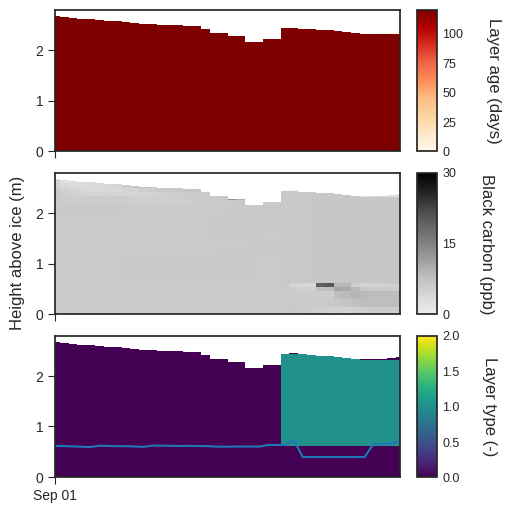

In [64]:
visualize_layers(ds, pd.date_range('2020-09-01', '2020-10-10'), ['layerage','layerBC','layertype'])
ga = ds.sel(time=pd.date_range('2020-09-01', '2020-10-10'))
plt.plot(ga.time, ga.albedo)

In [ ]:

# albedo.plot_1to1()
# for year in range(2019, 2025):
#     albedo.plot_timeseries(years=[year])

In [43]:
glacier, site = 'taku','Taku-1'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
ds = ds.sel(time=slice('2016-07-18','2016-07-19'), layer=0).max(dim='time')
print('TAKU')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')

l = LAPs(site)
print('Measured BC', l.bc_july, 'Measured dust', l.dust_july)
print()

glacier, site = 'gulkana','D'
ds = xr.open_dataset(base_fp + fn.replace('ratios3','test').format(g=glacier, s=site))

ds = ds.sel(time=slice('2024-08-21','2024-08-22'), layer=0).max(dim='time')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')
print('Measured BC between 2.9 and 10.5', 'Measured dust between 121-262')

TAKU
PEBSI BC 12.6    PEBSI dust 33.3    PEBSI Albedo 0.570
Measured BC 6.9 Measured dust 25

PEBSI BC 5.1    PEBSI dust 0.5    PEBSI Albedo 0.706
Measured BC between 2.9 and 10.5 Measured dust between 121-262


In [ ]:
#######################################################################################